In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from src.SizeEffects_functions import linear_regression_weighted
from matplotlib.collections import LineCollection
from src.process_data import  process_all_data, create_folder
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
from src.SizeEffects_functions import weighted_linear_regression_log2, shortest_path_best, df, df_parameters
plt.style.use('properties.mplstyle')

In [3]:
results_folder = "../results/Navigation/3D"
path_sizes = "../results/size_effects/3D"

create_folder(results_folder)
create_folder(path_sizes)

In [3]:
df

,type_perc,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,bond,2,128,2,0.00001,1,1.000,1.0,0.1,1,600,600,0.864485,0.000007,130.770000,0.039057,15724.353333,5.101384
1,bond,2,128,5,0.00001,1,1.000,1.0,0.1,1,600,600,0.867833,0.000007,130.631667,0.036682,15724.226667,4.842578
2,bond,2,256,5,0.00001,1,1.000,1.0,0.1,1,400,306,0.499460,0.000031,342.960784,1.033260,54616.777778,37.916007
3,bond,2,128,7,0.00001,1,1.000,1.0,0.1,1,600,600,0.870005,0.000008,130.541667,0.038797,15724.835000,5.188671
4,bond,2,128,10,0.00001,1,1.000,1.0,0.1,1,600,600,0.872239,0.000008,130.370000,0.037294,15716.511667,5.113005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19437,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,4,10,10,1.000000,0.000000,1022.000000,0.000000,35474.800000,647.639317
19438,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,5,10,10,1.000000,0.000000,1022.000000,0.000000,30872.900000,911.686623
19439,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,6,10,10,1.000000,0.000000,1022.000000,0.000000,25762.700000,817.995016
19440,bond,3,1024,262144,0.00010,8,0.125,1.0,0.5,7,10,10,1.000000,0.000000,1022.000000,0.000000,24127.400000,701.424522


In [4]:
df_parameters[(df_parameters['k']==1.0e-06) & (df_parameters['P0']==0.1) & (df_parameters['L']>128)]

,L,n_s,k,P0,Nt_min,Nt_max,fmin,fmax
4,256,1,0.000001,0.1,1966,16384,0.029999,0.25
5,512,1,0.000001,0.1,10485,65536,0.039997,0.25
6,1024,1,0.000001,0.1,31457,262144,0.030000,0.25
16,256,2,0.000001,0.1,1310,16384,0.019989,0.25
17,512,2,0.000001,0.1,5242,65536,0.019997,0.25
18,1024,2,0.000001,0.1,31457,262144,0.030000,0.25
30,256,4,0.000001,0.1,1310,16384,0.019989,0.25
31,512,4,0.000001,0.1,2621,65536,0.009998,0.25
32,1024,4,0.000001,0.1,10485,262144,0.009999,0.25
46,256,8,0.000001,0.1,655,16384,0.009995,0.25


In [6]:
df[
    (df['k'] == 1.0e-06) &
    (df['rho'] == 1/2) &
    (df['nc'] == 2) &
    (df['P0'] == 0.1) &
    (df['p0'] == 1.0) &
    (df['L']==1024)
].head()

,type_perc,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
3893,bond,3,1024,20971,0.000001,2,0.5,1.0,0.1,1,25,25,0.250915,0.000005,5067.52,119.669004,1.062517e+08,2.557962e+06
3929,bond,3,1024,31457,0.000001,2,0.5,1.0,0.1,1,25,25,0.253171,0.000005,4340.32,10.977207,1.369500e+08,3.444491e+05
3930,bond,3,1024,31457,0.000001,2,0.5,1.0,0.1,2,25,25,0.253215,0.000005,4393.32,10.599642,1.386026e+08,3.290386e+05
3959,bond,3,1024,41943,0.000001,2,0.5,1.0,0.1,1,25,25,0.255265,0.000005,3857.36,6.574162,1.623621e+08,2.746895e+05
3960,bond,3,1024,41943,0.000001,2,0.5,1.0,0.1,2,25,25,0.255241,0.000005,3905.04,6.120316,1.643540e+08,2.570695e+05


fmin = 0.0099992752075195 to n_s = 8
Order = 1
  Y = aX + b
  a = 1.161154 ± 0.002637
  b = 0.337332 ± 0.023927
  chi2_red = 70.2795

Order = 2
  Y = aX + b
  a = 1.151122 ± 0.001979
  b = 0.451745 ± 0.017977
  chi2_red = 130.7410

Order = 3
  Y = aX + b
  a = 1.142144 ± 0.001595
  b = 0.547348 ± 0.014443
  chi2_red = 196.7831

Order = 4
  Y = aX + b
  a = 1.130457 ± 0.001395
  b = 0.665556 ± 0.012691
  chi2_red = 232.4195

Order = 5
  Y = aX + b
  a = 1.132993 ± 0.001438
  b = 0.654379 ± 0.013055
  chi2_red = 197.9166

Order = 6
  Y = aX + b
  a = 1.127515 ± 0.001435
  b = 0.714514 ± 0.013043
  chi2_red = 188.9762

Order = 7
  Y = aX + b
  a = 1.123388 ± 0.001532
  b = 0.761949 ± 0.013859
  chi2_red = 166.2192

Order = 8
  Y = aX + b
  a = 1.109845 ± 0.001727
  b = 0.901499 ± 0.015765
  chi2_red = 95.6220



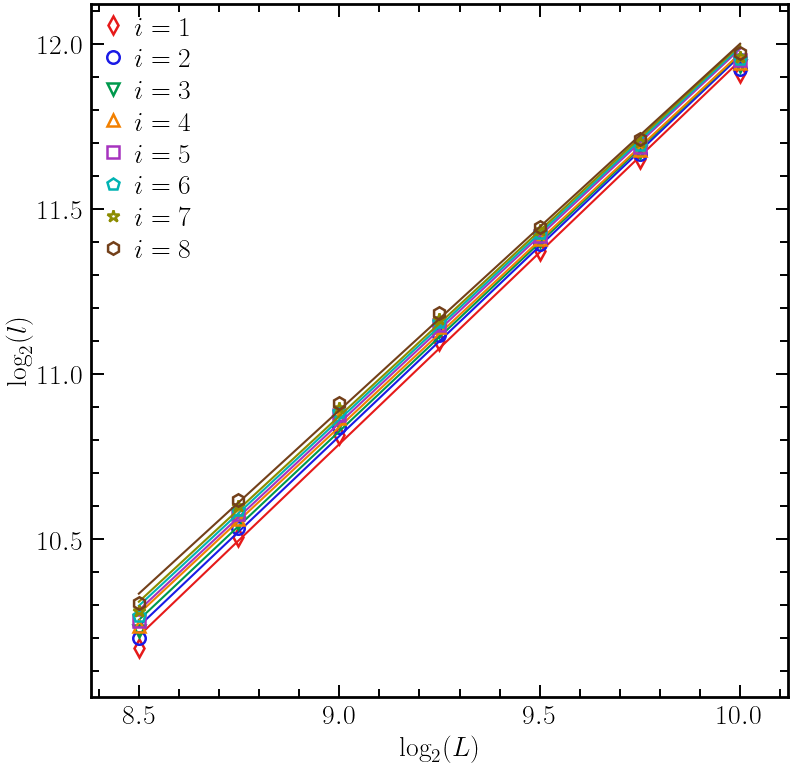

In [4]:
nc = 8
P0 = 0.1
p0 = 1.0
L_lst_filter = [256, 512, 1024]
#L_lst = [256, 304, 362, 430, 512, 608, 724, 861, 1024]
L_lst = [362, 430, 512, 608, 724, 861, 1024]
rho = 1 / nc
k = 1.0e-06

df_filter = shortest_path_best(L_lst_filter, L_lst, nc, k, rho, P0, p0)

orders = [i for i in range(1, nc + 1)]
colors = [
    (0.90, 0.10, 0.10),  # red
    (0.10, 0.10, 0.90),  # blue
    (0.00, 0.60, 0.30),  # green
    (0.95, 0.50, 0.00),  # orange
    (0.65, 0.20, 0.75),  # purple
    (0.00, 0.70, 0.70),  # teal
    (0.55, 0.55, 0.00),  # olive
    (0.45, 0.25, 0.10),  # brown
]
mew = 1.8
markers = ['d','o','v', '^','s', 'p','*', 'h']
fig, ax = plt.subplots(figsize=(9, 9))

X_all = []
Y_all = []
Yerr_all = []

for idx, ord in enumerate(orders):
    df_X = df_filter[df_filter['order'] == ord].copy()

    x = df_X["L"].values
    y = df_X["shortest_path"].values
    y_err = df_X["shortest_path_err"].values

    fit = weighted_linear_regression_log2(x, y, y_err)

    X = fit["X"]
    Y = fit["Y"]
    Y_err = fit["Y_err"]

    a = fit["a"]
    a_err = fit["a_err"]
    b = fit["b"]
    b_err = fit["b_err"]
    chi2_red = fit["chi2_red"]

    X_all.extend(X)
    Y_all.extend(Y)
    Yerr_all.extend(Y_err)

    ax.plot(
        X, Y,
        marker=markers[idx],
        color=colors[idx],
        ls="None",
        mew=mew,
        label=f'$i={ord}$'
    )

    X_fit = np.linspace(X.min(), X.max(), 300)
    Y_fit = a * X_fit + b

    ax.plot(
        X_fit, Y_fit,
        '-',
        color=colors[idx],
        #label=rf'$i={ord}: \; Y=({a:.3f}\pm{a_err:.3f})X + ({b:.3f}\pm{b_err:.3f})$'
    )

    print(f'Order = {ord}')
    print('  Y = aX + b')
    print(f'  a = {a:.6f} ± {a_err:.6f}')
    print(f'  b = {b:.6f} ± {b_err:.6f}')
    print(f'  chi2_red = {chi2_red:.4f}')
    print()

# ---------- ticks em log2 ----------
X_all = np.asarray(X_all)
Y_all = np.asarray(Y_all)
Yerr_all = np.asarray(Yerr_all)

pad_frac = 0.08

from matplotlib.ticker import MultipleLocator

# ---------- limites automáticos ----------
X_all = np.asarray(X_all)
Y_all = np.asarray(Y_all)
Yerr_all = np.asarray(Yerr_all)

pad_frac = 0.08

xmin, xmax = X_all.min(), X_all.max()
ymin, ymax = (Y_all - Yerr_all).min(), (Y_all + Yerr_all).max()

dx = pad_frac * (xmax - xmin)
dy = pad_frac * (ymax - ymin)

x0, x1 = xmin - dx, xmax + dx
y0, y1 = ymin - dy, ymax + dy

# define os limites
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)

# ---------- ticks ----------
tick_step_x = 0.5
tick_step_y = 0.5

xticks = np.arange(
    np.ceil(x0 / tick_step_x) * tick_step_x,
    np.floor(x1 / tick_step_x) * tick_step_x + 0.5 * tick_step_x,
    tick_step_x
)

yticks = np.arange(
    np.ceil(y0 / tick_step_y) * tick_step_y,
    np.floor(y1 / tick_step_y) * tick_step_y + 0.5 * tick_step_y,
    tick_step_y
)

ax.set_xticks(xticks)
ax.set_yticks(yticks)

# reaplica os limites, porque set_xticks/set_yticks pode expandir o eixo
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)

ax.set_xlabel(r'$\log_2(L)$')
ax.set_ylabel(r'$\log_2(l)$')

ax.legend()
plt.savefig(results_folder + f'shortest_nc_{nc}.pdf')
plt.show()

In [47]:
np.exp(4.5)

np.float64(90.01713130052181)

In [44]:
x = 2 ** np.linspace(8, 10, 9)
x_int = [int(i) for i in x]
print(x_int)

[256, 304, 362, 430, 512, 608, 724, 861, 1024]


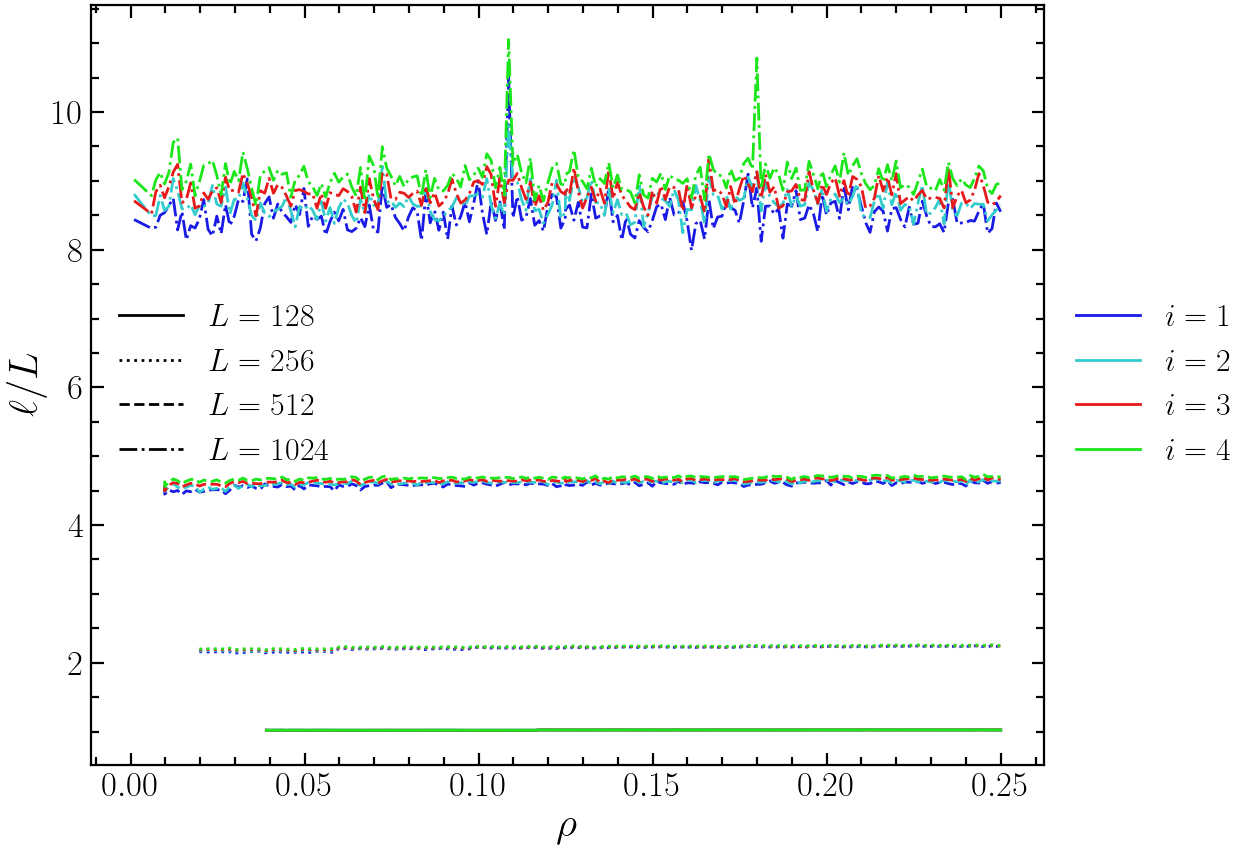

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

L_lst = [128, 256, 512, 1024]
nc = 4
orders = [i for i in range(1, nc+1)]

colors = [
    (0.1, 0.1, 0.9),  # blue
    (0.2, 0.8, 0.8),  # teal
    (0.9, 0.1, 0.1),  # red
    (0.1, 0.9, 0.1),  # green
]
fs_legend_global = 23
fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
lw_data = 2.0

tick_w = 1.6


ls = ['solid', 'dotted', 'dashed', 'dashdot']

fig, ax = plt.subplots(figsize=(13, 9))



# ======================
# Plot
# ======================
for idx, L in enumerate(L_lst):
    for idx_c, ord in enumerate(orders):
        df_sub = df[(df["L"]==L) & (df['nc']==nc) & (df['order']==ord)]
        
        x = np.asarray(df_sub['rho'])
        y = np.asarray(df_sub['shortest_path']/L)
        y_err = np.asarray(df_sub['shortest_path_err']/L)
        
        
        ax.plot(
            df_sub['rho'],
            df_sub['shortest_path']/L,
            ls=ls[idx],
            color=colors[idx_c],
            lw=lw_data
        )

ax.set_ylabel(r"$\ell/L$",fontsize=fs_labels)
ax.set_xlabel(r"$\rho$",fontsize=fs_labels)

# ======================
# Legenda interna → L (linestyle, preto)
# ======================
legend_L = [
    Line2D([0], [0],
           color='black',
           linestyle=ls[i],
           lw=lw_data,
           label=fr"$L={L_lst[i]}$")
    for i in range(len(L_lst))
]

leg1 = ax.legend(
    handles=legend_L,
#    loc='upper left',
    frameon=False,
    fontsize=fs_legend_local
)

# ======================
# Legenda externa → ordem i (cores)
# ======================
legend_i = [
    Line2D([0], [0],
           color=colors[i],
           lw=lw_data,
           label=fr"$i={orders[i]}$")
    for i in range(len(orders))
]

leg2 = ax.legend(
    handles=legend_i,
    bbox_to_anchor=(1.02, 0.5),   # x fora, y central
    loc='center left',
    borderaxespad=0.,
    frameon=False,
    fontsize=fs_legend_global
)

ax.tick_params(axis='both', which='both', width=tick_w, labelsize=fs_ticks)
ax.add_artist(leg1)
for spine in ax.spines.values():
    spine.set_linewidth(tick_w)

plt.tight_layout()
plt.savefig(path_sizes + "/shortest_from_rho.pdf")
plt.show()

ValueError: Sem dados para L=192, nc=4, ord=1, rho=0.25

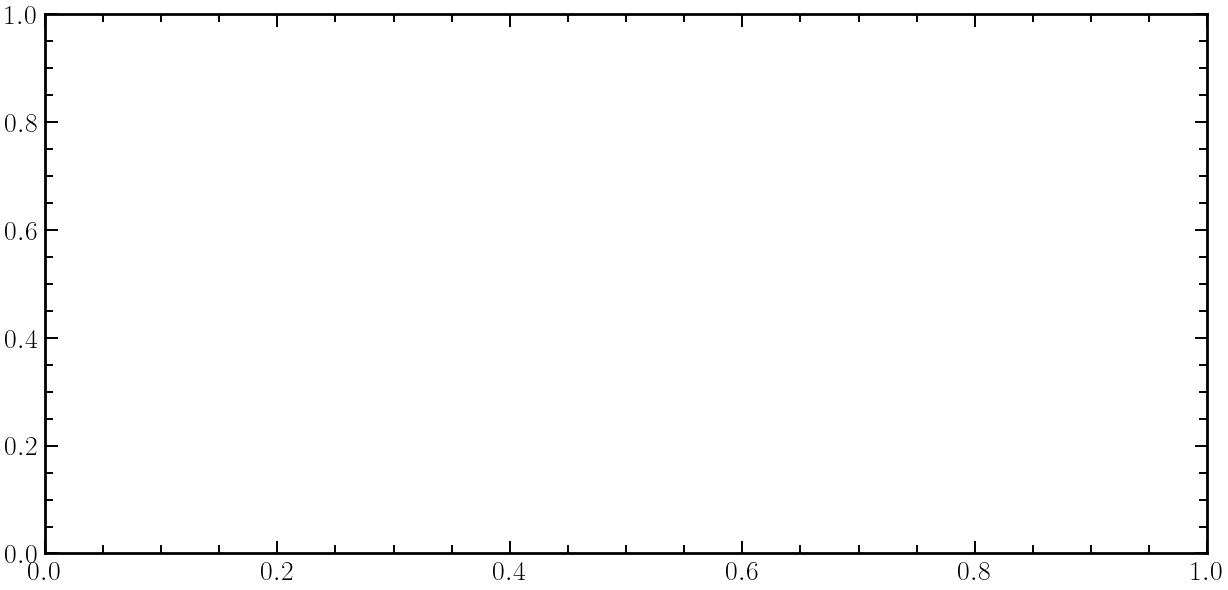

In [ ]:



# =========================
# USO
# =========================
nc = 4
orders = [i for i in range(1, nc+1)]
L_lst = [128, 192, 256, 384, 512, 1024]
rho = 1/nc

fig, ax = plot_all_orders_together_two_legends(
    df=df, L_lst=L_lst, nc=nc, orders=orders, rho=rho,
    figsize=(15, 7),
    fs_ticks=25, fs_labels=30,
    fs_leg_out=22, fs_leg_in=22,
    lw_fit=3.0
)
plt.savefig(results_folder + "/shortest_versus_L.png")
plt.show()


In [95]:
df.head()

,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,3,1024,3000,0.000001,4,0.001000,1.0,1.0,1,10,0.249340,0.000007,8640.2,220.007717,28385039.3,528240.943520
1,3,1024,3000,0.000001,4,0.001000,1.0,1.0,2,10,0.249459,0.000007,9017.5,200.162170,28386085.9,528286.233549
2,3,1024,3000,0.000001,4,0.001000,1.0,1.0,3,10,0.249516,0.000008,8919.5,158.944522,28386018.4,528036.591525
3,3,1024,3000,0.000001,4,0.001000,1.0,1.0,4,10,0.249544,0.000008,9236.5,176.047926,28384908.2,527771.393318
4,3,1024,3000,0.000001,4,0.006005,1.0,0.1,2,10,0.249439,0.000008,8692.8,237.853400,27656187.8,622644.031575


In [6]:
df[(df['rho']==0.125) & (df['dim']==3) & (df['nc']==8)]['L'].unique()


array([1024,  256,  512,  768,  128,  384,  192])

In [3]:
import numpy as np

def linear_regression_weighted(x, y, y_err, scale_by_chi2=True, eps=1e-15):
    """
    Regressão linear ponderada.
    Modelo: y = A x + B

    Se scale_by_chi2=True:
      - multiplica as incertezas dos parâmetros por sqrt(chi2_red) quando dof>0,
        o que corrige subestimação quando y_err não bate com a dispersão real.

    Retorna:
    A, B, sigma_A, sigma_B, chi2, chi2_red, R2, y_fit, cov
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y_err = np.asarray(y_err, dtype=float)

    # proteção
    y_err = np.maximum(y_err, eps)

    w = 1.0 / (y_err**2)

    S   = np.sum(w)
    Sx  = np.sum(w * x)
    Sy  = np.sum(w * y)
    Sxx = np.sum(w * x * x)
    Sxy = np.sum(w * x * y)

    Delta = S * Sxx - Sx**2
    if not np.isfinite(Delta) or Delta <= 0:
        raise ValueError("Delta inválido (problema numérico/degenerescência).")

    A = (S * Sxy - Sx * Sy) / Delta
    B = (Sxx * Sy - Sx * Sxy) / Delta

    y_fit = A * x + B

    # χ²
    chi2 = np.sum(w * (y - y_fit)**2)
    dof = len(x) - 2
    chi2_red = chi2 / dof if dof > 0 else np.nan

    # covariância (X^T W X)^-1 para [A, B]
    cov = np.array([[ S / Delta,   -Sx / Delta],
                    [-Sx / Delta,  Sxx / Delta]], dtype=float)

    # escala por chi2_red (se desejado e dof válido)
    if scale_by_chi2 and (dof > 0) and np.isfinite(chi2_red) and (chi2_red > 0):
        cov = cov * chi2_red

    sigma_A = float(np.sqrt(cov[0, 0]))
    sigma_B = float(np.sqrt(cov[1, 1]))

    # R² ponderado
    y_mean_w = Sy / S
    chi2_tot = np.sum(w * (y - y_mean_w)**2)
    R2 = 1.0 - chi2 / chi2_tot if chi2_tot > 0 else np.nan

    return A, B, sigma_A, sigma_B, chi2, chi2_red, R2, y_fit, cov

# $N_c = 8$

['$384$', '$416$', '$448$', '$480$', '$512$', '$600$', '$680$', '$768$', '$1024$']
['$150$', '$150$', '$100$', '$100$', '$50$', '$20$', '$20$', '$31$', '$10$']
   order              A      sigma_A         B   sigma_B        nu        R²
0      1  231187.031538  1121.827510  0.249173  0.000043  2.766667  0.999835
1      2  163006.596557  1127.267432  0.249078  0.000063  2.706061  0.999665
2      3  235084.370365   830.003186  0.249120  0.000031  2.766667  0.999913
3      4  235267.414180  1894.165040  0.249110  0.000072  2.766667  0.999546
4      5  338276.681315  1929.582553  0.249234  0.000051  2.827273  0.999772
5      6  233979.256485  1338.159850  0.249153  0.000051  2.766667  0.999771
6      7  479086.042925  1644.061211  0.249420  0.000030  2.887879  0.999918
7      8  161631.819634   824.772864  0.249103  0.000046  2.706061  0.999818
exp = 2.7742424242424244


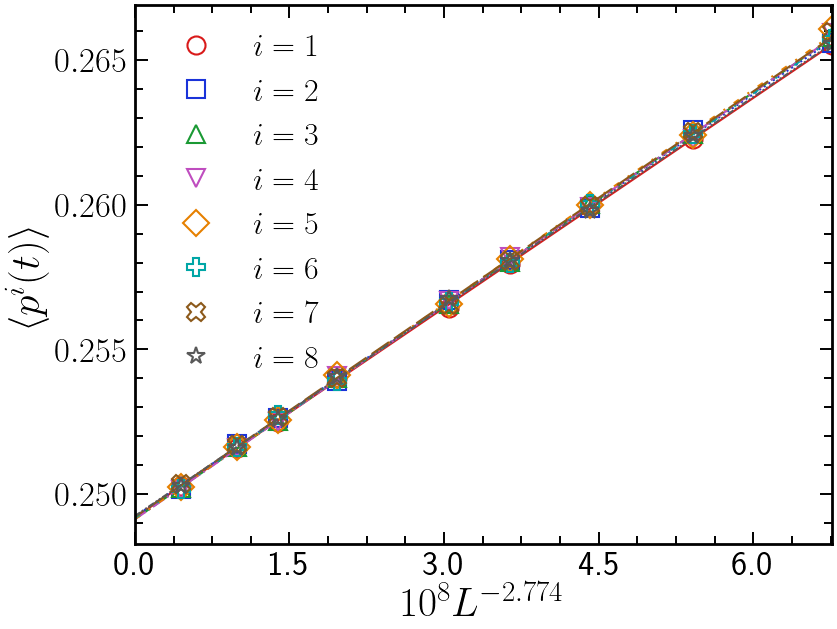

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

# =========================
# Inputs
# =========================
L_lst = [384, 416, 448, 480, 512, 600, 680, 768, 1024]
nc = 8
rho = 1/nc

fs_legend_global = 23
fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
mew = 1.5
ms = 13
tick_w = 1.6

markers = [
    "o", "s", "^", "v", "D", "P", "X", "*"
]

colors = [
    (0.85, 0.10, 0.10),  # vermelho forte
    (0.10, 0.20, 0.85),  # azul forte
    (0.10, 0.60, 0.20),  # verde escuro
    (0.75, 0.30, 0.75),  # magenta
    (0.90, 0.50, 0.00),  # laranja forte
    (0.00, 0.65, 0.65),  # ciano escuro
    (0.55, 0.35, 0.10),  # marrom
    (0.35, 0.35, 0.35),  # cinza escuro
]

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

orders = [i for i in range(1, nc + 1)]

l_latex = []
ns_latex = []

fig, ax = plt.subplots(figsize=(9, 7))

l = np.asarray([1/i for i in L_lst], float)

data_pi = {"order": [], "L_lst": [], "pc": [], "pc_err": []}

data = {"order": [], "A": [], "sigma_A": [], "B": [], "sigma_B": [], "nu": [], "R²": []}
nu = np.linspace(0.1, 6.1, 100)

# =========================
# Scan em nu para achar melhor por order
# =========================
for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]

        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

        if ord == 1:
            l_latex.append(f'${L}$')
            ns_latex.append(f'${int(df_sub['N_samples'].values[0])}$')

    pc_lst = np.asarray(pc_lst, float)
    pc_err_lst = np.asarray(pc_err_lst, float)

    for ni in nu:
        x = np.asarray([1 / (L**ni) for L in L_lst], float)
        y = pc_lst
        y_err = pc_err_lst

        parms = linear_regression_weighted(x, y, y_err)
        A, B, sigma_A, sigma_B, R2 = parms[0], parms[1], parms[2], parms[3], parms[6]

        data["order"].append(ord)
        data["nu"].append(ni)
        data["R²"].append(R2)
        data["A"].append(A)
        data["B"].append(B)
        data["sigma_A"].append(sigma_A)
        data["sigma_B"].append(sigma_B)

print(l_latex)
print(ns_latex)

df_new = pd.DataFrame(data=data)

df_best_per_order = (
    df_new.loc[df_new.groupby("order")["R²"].idxmax()]
          .sort_values("order")
          .reset_index(drop=True)
)

print(df_best_per_order)

exp = df_best_per_order['nu'].mean()
print("exp =", exp)

# =========================
# Scaling do eixo x: x_scaled = 10^power * L^{-exp}
# =========================
power = 8
scale = 10**power

x_base = l**exp
x_scaled = x_base * scale
x_max = float(np.max(x_scaled))

# =========================
# Plot final
# =========================
for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

    pc = np.asarray(pc_lst, float)
    pc_err = np.asarray(pc_err_lst, float)

    data_pi['order'].append(ord)
    data_pi['L_lst'].append(l)
    data_pi['pc'].append(pc)
    data_pi['pc_err'].append(pc_err)

    parms = linear_regression_weighted(x_scaled, pc, pc_err)

    x_fit = np.linspace(0, x_max, 500)
    y_fit = parms[0] * x_fit + parms[1]

    ax.plot(x_fit, y_fit, ls=ls[idx], color=colors[idx])
    ax.plot(x_scaled, pc, linestyle='none', ms=ms, mew=mew,
            marker=markers[idx], color=colors[idx], label=f'$i = {ord}$')

df_pi = pd.DataFrame(data=data_pi)

# =========================
# Ticks bonitos: 0.0, 0.5, 1.0, ...
# =========================
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.xaxis.offsetText.set_visible(False)

ax.set_xlim([0, x_max])

ax.set_xlabel(fr"$10^{{{power}}}L^{{-{exp:.3f}}}$", fontsize=fs_labels)
ax.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)

ax.legend(fontsize=fs_legend_local)
ax.tick_params(axis='both', which='major', labelsize=fs_ticks)
plt.savefig(path_sizes + f"/L_versus_p_nc_{nc}.pdf")
plt.show()

# $N_c = 4$

   order             A     sigma_A         B   sigma_B        nu        R²
0      1  63828.392379  291.267809  0.248995  0.000034  2.706061  0.999854
1      2  90708.465806  349.209663  0.249118  0.000028  2.766667  0.999896
2      3  64713.119821  363.485860  0.249036  0.000041  2.706061  0.999779
3      4  91882.379694  485.162284  0.249097  0.000039  2.766667  0.999805
exp = 2.7363636363636368
['$256$', '$283$', '$320$', '$348$', '$384$', '$443$', '$512$', '$768$', '$1024$']
['$350$', '$200$', '$200$', '$130$', '$171$', '$60$', '$80$', '$30$', '$21$']


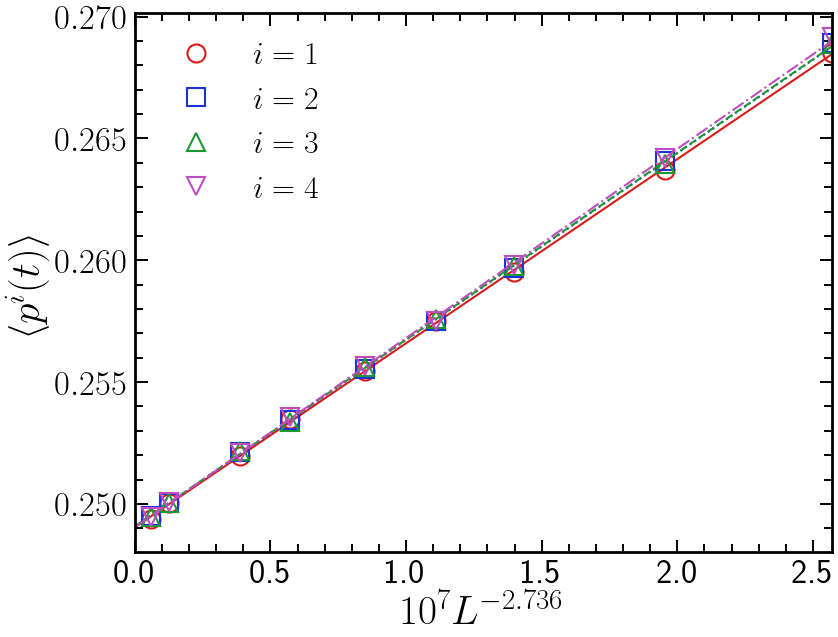

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

# =========================
# Inputs
# =========================
L_lst = [256, 283, 320, 348, 384, 443, 512, 768, 1024]
nc = 4
rho = 1/nc

fs_legend_global = 23
fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
mew = 1.5
ms = 13
tick_w = 1.6

markers = ["o", "s", "^", "v", "D", "P", "X", "*"]

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

colors = [
    (0.85, 0.10, 0.10),
    (0.10, 0.20, 0.85),
    (0.10, 0.60, 0.20),
    (0.75, 0.30, 0.75),
    (0.90, 0.50, 0.00),
    (0.00, 0.65, 0.65),
    (0.55, 0.35, 0.10),
    (0.35, 0.35, 0.35),
]

orders = [i for i in range(1, nc + 1)]

fig, ax = plt.subplots(figsize=(9, 7))

l = np.asarray([1/i for i in L_lst], float)

data_pi = {"order": [], "L_lst": [], "pc": [], "pc_err": []}

data = {"order": [], "A": [], "sigma_A": [], "B": [], "sigma_B": [], "nu": [], "R²": []}
nu = np.linspace(0.1, 6.1, 100)

l_latex = []
ns_latex = []

# =========================
# Scan em nu para achar melhor por order
# =========================
for idx, ord in enumerate(orders):
    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]

        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

        if ord == 1:
            l_latex.append(L)
            ns_latex.append(int(df_sub['N_samples'].values[0]))

    pc_lst = np.asarray(pc_lst, float)
    pc_err_lst = np.asarray(pc_err_lst, float)

    for ni in nu:
        x = np.asarray([1 / (L**ni) for L in L_lst], float)
        y = pc_lst
        y_err = pc_err_lst

        parms = linear_regression_weighted(x, y, y_err)
        A, B, sigma_A, sigma_B, R2 = parms[0], parms[1], parms[2], parms[3], parms[6]

        data["order"].append(ord)
        data["nu"].append(ni)
        data["R²"].append(R2)
        data["A"].append(A)
        data["B"].append(B)
        data["sigma_A"].append(sigma_A)
        data["sigma_B"].append(sigma_B)

df_new = pd.DataFrame(data=data)

df_best_per_order = (
    df_new.loc[df_new.groupby("order")["R²"].idxmax()]
          .sort_values("order")
          .reset_index(drop=True)
)

print(df_best_per_order)

exp = df_best_per_order['nu'].mean()
print("exp =", exp)

# =========================
# Scaling do eixo x: x_scaled = 10^power * L^{-exp}
# =========================
power = 7
scale = 10**power

x_base = l**exp                 # L^{-exp}
x_scaled = x_base * scale       # 10^power * L^{-exp}
x_max = float(np.max(x_scaled))

ns_latex = []
l_latex = []
# =========================
# Plot (mantendo linearidade)
# =========================
for idx, ord in enumerate(orders):
    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])
        if(ord == 1):
            ns_latex.append(f'${df_sub["N_samples"].values[0]}$')
            l_latex.append(f'${L}$')
    pc = np.asarray(pc_lst, float)
    pc_err = np.asarray(pc_err_lst, float)

    data_pi['order'].append(ord)
    data_pi['L_lst'].append(l)
    data_pi['pc'].append(pc)
    data_pi['pc_err'].append(pc_err)

    # fit em x_scaled (não em x_base)
    parms = linear_regression_weighted(x_scaled, pc, pc_err)

    x_fit = np.linspace(0, x_max, 500)
    y_fit = parms[0] * x_fit + parms[1]

    ax.plot(x_fit, y_fit, ls=ls[idx], color=colors[idx])
    ax.plot(x_scaled, pc, linestyle='none', ms=ms, mew=mew,
            marker=markers[idx], color=colors[idx], label=f'$i = {ord}$')
print(l_latex)
print(ns_latex)
df_pi = pd.DataFrame(data=data_pi)

# =========================
# Ticks bonitos (0.0, 0.5, 1.0, ...)
# =========================
ax.xaxis.set_major_locator(MaxNLocator(6))            # ~6 ticks principais
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.xaxis.offsetText.set_visible(False)

ax.set_xlim([0, x_max])

ax.set_xlabel(fr"$10^{{{power}}}L^{{-{exp:.3f}}}$", fontsize=fs_labels)
ax.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)

ax.legend(fontsize=fs_legend_local)
ax.tick_params(axis='both', which='major', labelsize=fs_ticks)
plt.savefig(path_sizes + f"/L_versus_p_nc_{nc}.pdf")
plt.show()

# $N_c = 2$

[256, 272, 296, 312, 336, 360, 384, 424, 464, 512, 768, 849, 928, 1024]
[101, 100, 100, 100, 100, 75, 151, 75, 75, 51, 32, 10, 10, 10]
exp = 2.584848484848485
   order             A     sigma_A         B   sigma_B        nu        R²
0      1  18290.666029  117.495825  0.248953  0.000018  2.645455  0.999505
1      2   9386.815884   36.972776  0.248932  0.000011  2.524242  0.999814


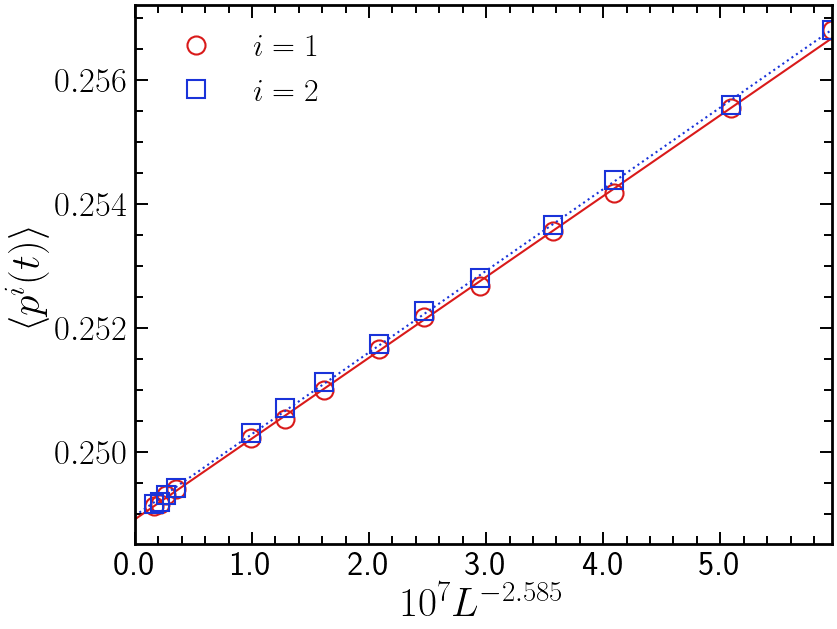

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

L_lst = [256, 272, 296, 312, 336, 360, 384, 424, 464, 512, 768, 849, 928, 1024]
nc = 2
rho = 1/nc

fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
mew = 1.5
ms = 13

markers = ["o","s","^","v","D","P","X","*"]

colors = [
    (0.85, 0.10, 0.10),
    (0.10, 0.20, 0.85),
]

ls = ['solid', 'dotted', 'dashed', 'dashdot']

orders = [i for i in range(1, nc+1)]

fig, ax = plt.subplots(figsize=(9, 7))

l = np.asarray([1/i for i in L_lst], float)

data = {"order": [], "A": [], "sigma_A": [], "B": [], "sigma_B": [], "nu": [], "R²": []}
nu = np.linspace(0.1, 6.1, 100)
ns_latex = []
l_latex = []
# =========================
# Encontrar melhor expoente
# =========================plt.savefig(path_sizes + f"/L_versus_p_nc_{nc}.pdf")
for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L']==L)&(df['nc']==nc)&(df['rho']==rho)&(df['order']==ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])
    
        if(ord == 1):
            ns_latex.append(df_sub["N_samples"].values[0])
            l_latex.append(L)
    
    pc_lst = np.asarray(pc_lst,float)
    pc_err_lst = np.asarray(pc_err_lst,float)

    for ni in nu:
        x = np.asarray([1/(L**ni) for L in L_lst],float)
        parms = linear_regression_weighted(x, pc_lst, pc_err_lst)

        data["order"].append(ord)
        data["nu"].append(ni)
        data["R²"].append(parms[6])
        data["A"].append(parms[0])
        data["B"].append(parms[1])
        data["sigma_A"].append(parms[2])
        data["sigma_B"].append(parms[3])

print(l_latex)
print(ns_latex)
df_new = pd.DataFrame(data)

df_best = (
    df_new.loc[df_new.groupby("order")["R²"].idxmax()]
    .sort_values("order")
    .reset_index(drop=True)
)

exp = df_best["nu"].mean()
print("exp =", exp)
print(df_best)
# =========================
# Escala 10^7
# =========================
power = 7
scale = 10**power

x_base = l**exp
x_scaled = x_base * scale
x_max = float(np.max(x_scaled))

# =========================
# Plot
# =========================
for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L']==L)&(df['nc']==nc)&(df['rho']==rho)&(df['order']==ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

    pc = np.asarray(pc_lst,float)
    pc_err = np.asarray(pc_err_lst,float)

    parms = linear_regression_weighted(x_scaled, pc, pc_err)

    x_fit = np.linspace(0, x_max, 500)
    y_fit = parms[0]*x_fit + parms[1]

    ax.plot(x_fit, y_fit, ls=ls[idx], color=colors[idx])
    ax.plot(x_scaled, pc, linestyle='none',
            marker=markers[idx], ms=ms, mew=mew,
            color=colors[idx],
            label=f'$i = {ord}$')

# =========================
# Ticks limpos
# =========================
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.xaxis.offsetText.set_visible(False)

ax.set_xlim([0, x_max])

ax.set_xlabel(fr"$10^{{{power}}}L^{{-{exp:.3f}}}$", fontsize=fs_labels)
ax.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)

ax.legend(fontsize=fs_legend_local)
ax.tick_params(axis='both', which='major', labelsize=fs_ticks)
plt.savefig(path_sizes + f"/L_versus_p_nc_{nc}.pdf")
plt.show()

In [14]:
def format_param_parenthesis(value, error):
    """
    Formato: valor(erro)
    Erro com 1 dígito significativo.
    Nunca usa notação científica.
    """

    if error == 0 or np.isnan(error):
        return f"{value}"

    exponent = int(math.floor(math.log10(abs(error))))
    
    # número de casas decimais necessárias
    decimals = -exponent if exponent < 0 else 0

    # erro com 1 dígito significativo
    error_rounded = round(error, decimals)
    value_rounded = round(value, decimals)

    # converte erro para inteiro na casa correta
    error_int = int(round(error_rounded * 10**decimals))

    # formata valor com número fixo de casas
    value_str = f"{value_rounded:.{decimals}f}"

    return f"{value_str}({error_int})"
def format_legend(A, sigma_A, B, sigma_B, nu):

    A_str = format_param_parenthesis(A, sigma_A)
    B_str = format_param_parenthesis(B, sigma_B)

    return (
        rf"$\nu = {nu:.3f}$" + "\n" +
        rf"$A = {A_str}$" + "\n" +
        rf"$B = {B_str}$"
    )

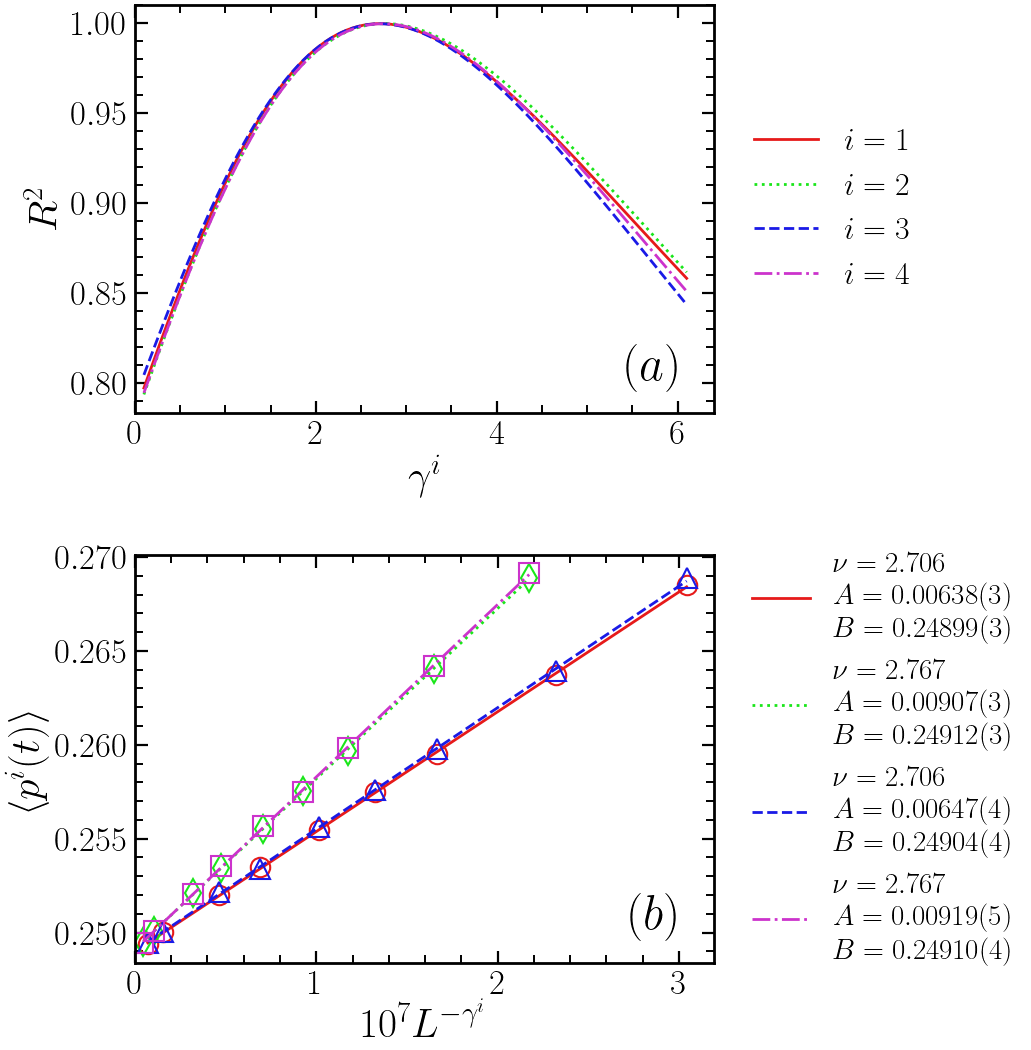

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Espera-se que existam:
# df, df_pi
# linear_regression_weighted(x,y,y_err) -> (A,B,sA,sB,chi2,chi2_red,R2,y_fit)
# format_legend(A, sigma_A, B, sigma_B, nu)

nu = np.linspace(0.1, 6.1, 100)

fs_ticks = 25
fs_labels = 30
lw_data = 2.0
tick_w = 1.6
ms = 14
L_lst = [256, 283, 320, 348, 384, 443, 512, 768, 1024]
markers = ["o", "d", "^", "s", "D", "v"]
colors = [(0.9,0.1,0.1),
          (0.1,0.9,0.1),
          (0.1,0.1,0.9),
          (0.8,0.2,0.8)]

# ======================================================
# Figura 2x1
# ======================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
ax_top = axes[0]
ax_bot = axes[1]
ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]
# ======================================================
# PLOT DE CIMA: R² vs nu (4 curvas)
# ======================================================
data = {"order": [], "A": [], "sigma_A": [], "B": [], "sigma_B": [], "nu": [], "R²": []}
nc = 4
rho = 1/nc
orders = [i for i in range(1, nc+1)]

for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []
    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

    pc_lst = np.asarray(pc_lst, float)
    pc_err_lst = np.asarray(pc_err_lst, float)

    for ni in nu:
        x = np.asarray([1 / (L**ni) for L in L_lst], float)
        y = pc_lst
        y_err = pc_err_lst

        parms = linear_regression_weighted(x, y, y_err)
        A, B, sigma_A, sigma_B, R2 = parms[0], parms[1], parms[2], parms[3], parms[6]

        data["order"].append(ord)
        data["nu"].append(ni)
        data["R²"].append(R2)
        data["A"].append(A)
        data["B"].append(B)
        data["sigma_A"].append(sigma_A)
        data["sigma_B"].append(sigma_B)

df_new = pd.DataFrame(data=data)

df_best_per_order = (
    df_new.loc[df_new.groupby("order")["R²"].idxmax()]
          .sort_values("order")
          .reset_index(drop=True)
)

# curvas R²(nu)
for idx, ord in enumerate(orders):
    df_ord = df_new[df_new["order"] == ord]
    ax_top.plot(df_ord["nu"], df_ord["R²"], lw=lw_data, color=colors[idx], ls=ls[idx], label=fr"$i={ord}$")

ax_top.set_xlabel(r"$\gamma^i$", fontsize=fs_labels)
ax_top.set_ylabel(r"$R^2$", fontsize=fs_labels)
ax_top.tick_params(axis='both', which='major', labelsize=fs_ticks, width=tick_w)
ax_top.set_xlim(0)

# legenda fora (direita), centralizada
leg_top = ax_top.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=False,
    fontsize=fs_ticks-2
)

# ======================================================
# PLOT DE BAIXO: ajuste com nu ótimo por ordem
#   - eixo x reescalado: x' = 10^7 * L^{-nu}
#   - slope reescalado de forma consistente: A' = A / 10^7
# ======================================================
for index in range(nc):

    L_inv = np.asarray(df_pi.iloc[index]["L_lst"], float)  # já é 1/L
    pc = np.asarray(df_pi.iloc[index]["pc"], float)
    pc_err = np.asarray(df_pi.iloc[index]["pc_err"], float)

    A = df_best_per_order.iloc[index]["A"]
    B = df_best_per_order.iloc[index]["B"]
    nu_best = df_best_per_order.iloc[index]["nu"]
    sigma_A = df_best_per_order.iloc[index]["sigma_A"]
    sigma_B = df_best_per_order.iloc[index]["sigma_B"]

    # variável original
    x0 = L_inv**nu_best

    # reescala para remover ×10^-7 do eixo: x' = 10^7 x0
    x = 1e7 * x0

    # reescala A (e seu erro) para manter o mesmo ajuste em função de x'
    A_plot = A / 1e7
    sigma_A_plot = sigma_A / 1e7
    B_plot = B
    sigma_B_plot = sigma_B

    ax_bot.plot(
        x, pc,
        marker=markers[index],
        linestyle='none',
        color=colors[index],
        ms = ms,
        mew=mew
    )

    x_fit = np.linspace(np.min(x), np.max(x), 200)
    label_text = format_legend(A_plot, sigma_A_plot, B_plot, sigma_B_plot, nu_best)

    ax_bot.plot(
        x_fit, A_plot * x_fit + B_plot,
        color=colors[index],
        lw=2,
        label=label_text
    )

ax_bot.set_xlim(0)
ax_bot.set_xlabel(r"$10^{7} L^{-\gamma^i}$", fontsize=fs_labels)
ax_bot.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)
ax_bot.tick_params(axis='both', which='major', labelsize=fs_ticks, width=tick_w)

# legenda fora (direita), centralizada
leg_bot = ax_bot.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=False,
    fontsize=fs_ticks-4
)
labels_alfa = ["$(a)$", "$(b)$"]
fs_text = 35
ax_bot.text(0.95, 0.05, labels_alfa[1],
        transform=ax_bot.transAxes, ha='right', va='bottom',
        fontsize=fs_text)

ax_top.text(0.95, 0.05, labels_alfa[0],
        transform=ax_top.transAxes, ha='right', va='bottom',
        fontsize=fs_text)

#  espaço para as legendas do lado
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.savefig(path_sizes + f"/R_L_ni_{nc}.pdf")
plt.show()

[1, 2, 3, 4]


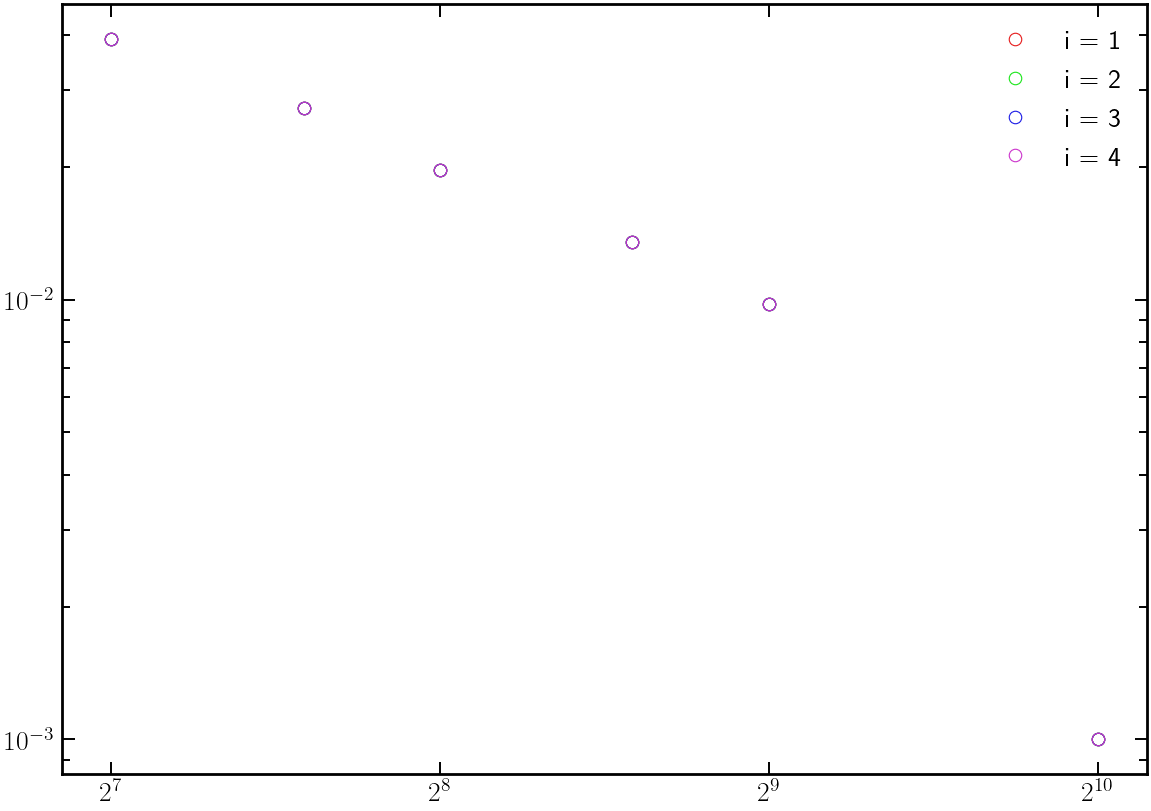

In [22]:
nc = 4
rho = 1/nc
ord = 1
L_unique = np.sort(df[(df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]['L'].unique())
L_lst = [128, 192, 256, 384, 512, 1024]
orders = [i for i in range(1, nc+1)]
print(orders)
for ord in orders:
    rho_min = [df[(df['nc'] == nc)  & (df['order'] == ord) & (df['L'] == L)]['rho'].min() for L in L_lst]
    plt.plot(L_lst, rho_min, 'o', label=f'i = {ord}')

plt.legend()
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.show()
